<a href="https://colab.research.google.com/github/yakoubbenabbas/Machine-Learning-supervised-learning-/blob/main/5G_energy_consumption_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score


In [ ]:
data = pd.read_csv("/content/5G_energy_consumption_dataset.csv")           #reading the file
data

,Time,BS,Energy,load,ESMODE,TXpower
0,20230101 010000,B_0,64.275037,0.487936,0.0,7.101719
1,20230101 020000,B_0,55.904335,0.344468,0.0,7.101719
2,20230101 030000,B_0,57.698057,0.193766,0.0,7.101719
3,20230101 040000,B_0,55.156951,0.222383,0.0,7.101719
4,20230101 050000,B_0,56.053812,0.175436,0.0,7.101719
...,...,...,...,...,...,...
92624,20230102 170000,B_1018,14.648729,0.087538,0.0,7.325859
92625,20230102 180000,B_1018,14.648729,0.082635,0.0,7.325859
92626,20230102 210000,B_1018,13.452915,0.055538,0.0,7.325859
92627,20230102 220000,B_1018,13.602392,0.058077,0.0,7.325859


In [ ]:
data.info()             #displaying information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92629 entries, 0 to 92628
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Time     92629 non-null  object 
 1   BS       92629 non-null  object 
 2   Energy   92629 non-null  float64
 3   load     92629 non-null  float64
 4   ESMODE   92629 non-null  float64
 5   TXpower  92629 non-null  float64
dtypes: float64(4), object(2)
memory usage: 4.2+ MB


In [ ]:
data.isnull().sum()          #checking for corrupted or missing values

,0
Time,0
BS,0
Energy,0
load,0
ESMODE,0
TXpower,0


In [ ]:
data.duplicated().sum()            #checking for duplicates

np.int64(0)

In [ ]:
data = data.drop(columns="ESMODE")           #decided to drop this column due to it having only zeros which makes it not needed for our machine learning model

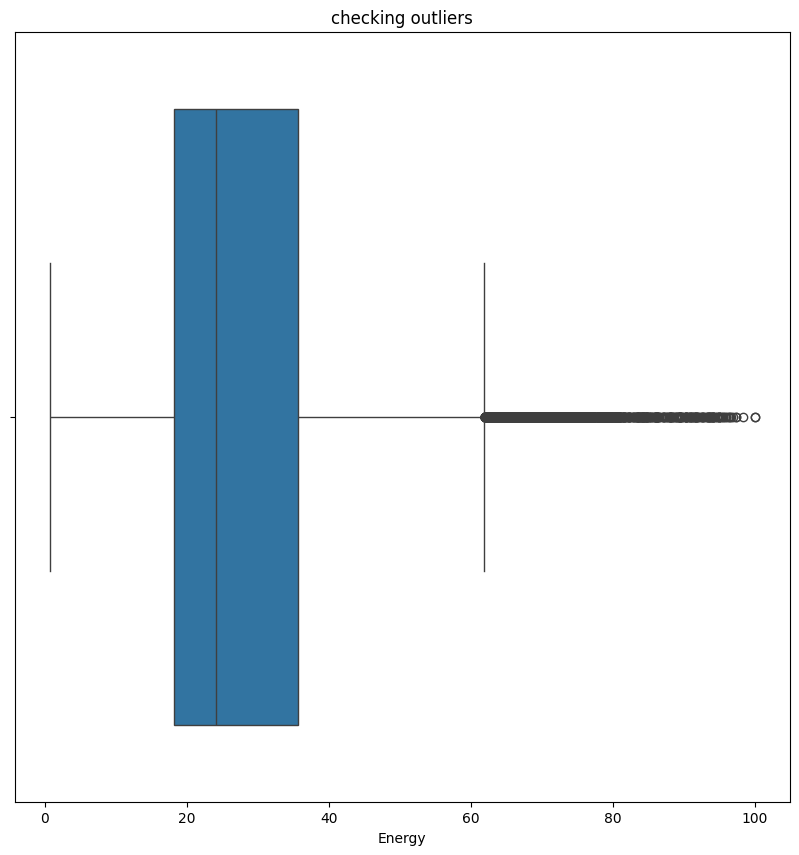

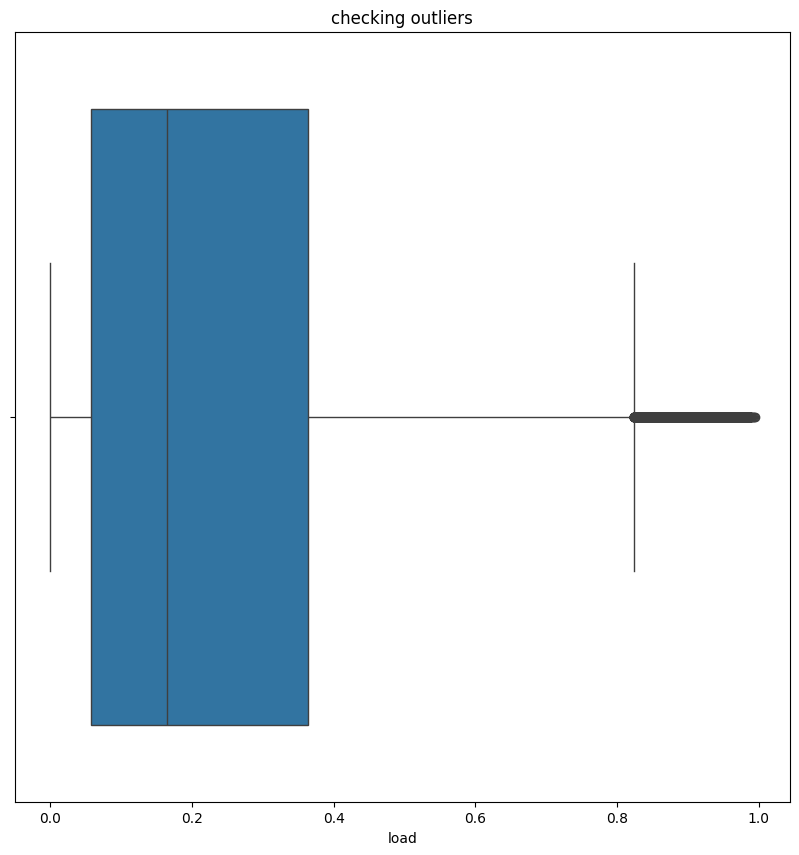

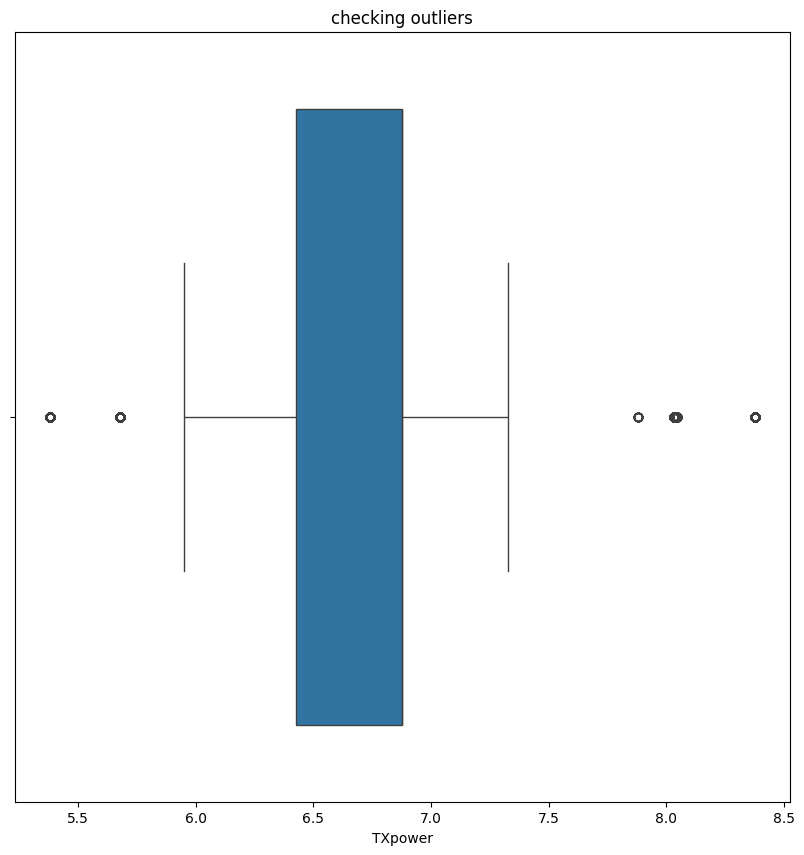

In [ ]:
numeric_chart = data.select_dtypes(include=["number"]).columns                    #displaying a box plot for numerical features only to check for outliers
for col in numeric_chart:
  plt.figure(figsize=(10,10))
  sns.boxplot(x=data[col])
  plt.title("checking outliers")
  plt.show()

In [ ]:
data["Energy"].sort_values(ascending=False).head(10)             #checking the values to see if the outliers are off the normal range

,Energy
43036,100.000000
43035,100.000000
43048,98.355755
43052,97.309417
43049,97.309417
43050,97.010463
43051,96.711510
43047,96.562033
43014,96.412556
12326,96.263079


In [ ]:
data["load"].sort_values(ascending=False).head(10)

,load
36708,0.993957
70134,0.993064
36772,0.992266
36685,0.990532
36741,0.989351
70959,0.989266
20939,0.988074
25812,0.987360
25821,0.987250
25809,0.986940


In [ ]:
data["TXpower"].sort_values(ascending=False).head(10)

,TXpower
90620,8.375336
90619,8.375336
90618,8.375336
90617,8.375336
90616,8.375336
90615,8.375336
90614,8.375336
90613,8.375336
90612,8.375336
90611,8.375336


In [ ]:
#even though  there are outliers available on our box plot they dont't really hurt our data set as you can see after i sorted values the data is in great shape so no need for removing them

In [ ]:
data = pd.get_dummies(data,columns=["BS"])            #hot encoded the BS feature to transform it into a numerical column to make it simpler for our machine learning model to understamd
data

,Time,Energy,load,TXpower,BS_B_0,BS_B_1,BS_B_10,BS_B_100,BS_B_1003,BS_B_1004,...,BS_B_990,BS_B_991,BS_B_992,BS_B_993,BS_B_994,BS_B_995,BS_B_996,BS_B_997,BS_B_998,BS_B_999
0,20230101 010000,64.275037,0.487936,7.101719,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,20230101 020000,55.904335,0.344468,7.101719,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,20230101 030000,57.698057,0.193766,7.101719,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,20230101 040000,55.156951,0.222383,7.101719,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,20230101 050000,56.053812,0.175436,7.101719,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92624,20230102 170000,14.648729,0.087538,7.325859,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
92625,20230102 180000,14.648729,0.082635,7.325859,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
92626,20230102 210000,13.452915,0.055538,7.325859,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
92627,20230102 220000,13.602392,0.058077,7.325859,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
x = data[["load","TXpower"]]                #setting target variable x (Energy because the goal is to predict energy consumption) and features y (load and TXpower they both effect the use of energy)
y = data["Energy"]

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)           #splitting into train and test

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)                          #decided to use linear regression algorithm (multiple linear regression is most suitable for this data)
y_pred = model.predict(x_test)
print(f"predicted energy consumption:{y_pred}")       #successfully predicted energy consumption

predicted energy consumption:[37.61633144 21.89853947 17.36031032 ... 45.55132158 35.31608976
 25.53821324]


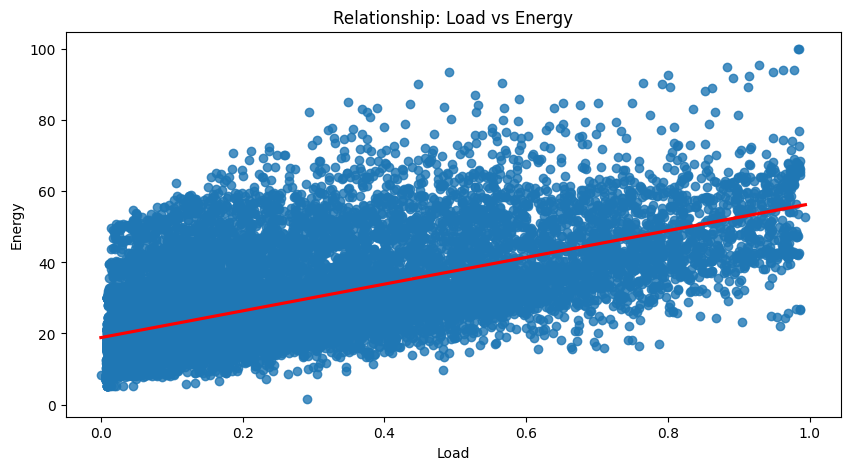

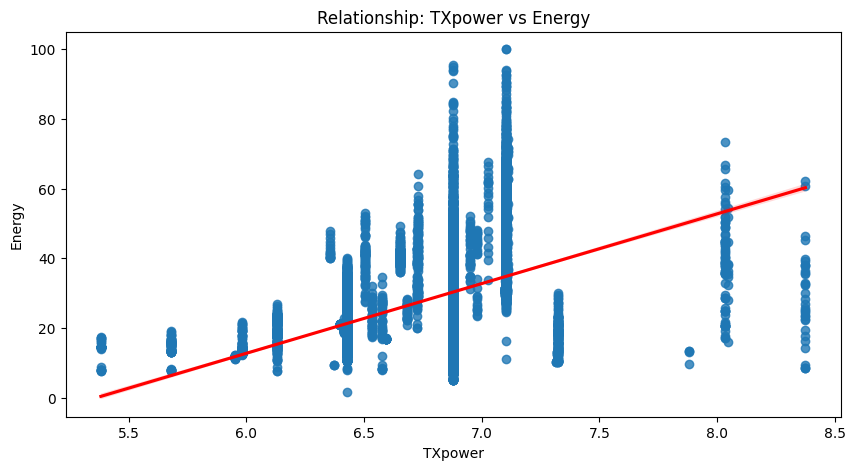

In [ ]:
plt.figure(figsize=(10, 5))
sns.regplot(x=x_test['load'], y=y_test,  line_kws={'color':'red'})
plt.title('Relationship: Load vs Energy')
plt.xlabel('Load')
plt.ylabel('Energy')
plt.show()
                                                                        #visualizing the relationship to see our model accuracy
plt.figure(figsize=(10, 5))
sns.regplot(x=x_test['TXpower'], y=y_test,line_kws={'color':'red'})
plt.title('Relationship: TXpower vs Energy')
plt.xlabel('TXpower')
plt.ylabel("Energy")
plt.show()

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rse = root_mean_squared_error(y_test,y_pred)
r2score = r2_score(y_test,y_pred)
print(f"mean absolute error: {mae}")              #checking if the model is great enough the higher the r2 the better and the lower the others the better
print(f"mean squared error: {mse}")
print(f"root mean squared error: {rse}")
print(f"r2 score: {r2score}")

mean absolute error: 7.236509742961431
mean squared error: 92.2294841783059
root mean squared error: 9.60361828574553
r2 score: 0.5140861507708239


In [ ]:
#step 6:
#my model has an r2 score of 0.51 which means my model isn't performing well in order to improve this we can consider the time 5g is being used or the type of hardware (some hardware devices extract energy more than other)
#maybe if i took these things into consideration my model would perform 10x better when it comes to predicting energy consumption or simply to experiment with other machine learning algorithms

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
                                                                                     #ML predcition model using gradient booster algorithm
model = GradientBoostingRegressor()
model.fit(x_train,y_train)

y_pred2 = model.predict(x_test)

print(f"energy consumption predicted (using Gradient Booster algorithm): {y_pred2}")


6

energy consumption predicted (using Gradient Booster algorithm): [47.51327543 14.86450189 20.18800748 ... 38.63794682 29.97482986
 34.85487529]


6

In [ ]:
mae = mean_absolute_error(y_test,y_pred2)
mse = mean_squared_error(y_test,y_pred2)
rmse = root_mean_squared_error(y_test,y_pred2)
r2score = r2_score(y_test,y_pred2)
print(f"mean absolute error: {mae}")              #checking if the model is great enough the higher the r2 the better and the lower the others the better
print(f"mean squared error: {mse}")
print(f"root mean squared error: {rmse}")
print(f"r2 score: {r2score}")

mean absolute error: 3.9944605289279904
mean squared error: 28.903340913854958
root mean squared error: 5.376182745578405
r2 score: 0.8477218672080795


In [ ]:
#In Conclusion, the gradient Booster algorithm is far more superior and displayed better results than the multiple Linear regression model.
#and the reason for this when you check the metrics errors for the  gradient booster model  they are lower and the r2 score is higher displaying a result of 0.84 compared to the other model 0.51